# 08 · 實戰：Kaggle 風格完整專案

把前七課全部串起來，走一遍表格資料競賽的標準流程：資料 → 切分 → XGBoost + early stopping → 調參 → 測試集驗收 → SHAP 解讀。這是 boosting 模組的收尾。

## 學習目標

- 串起 boosting 的完整工作流程
- 用驗證集 + early stopping + 隨機搜尋產出一個調好的模型
- 在測試集誠實驗收，並用 SHAP 交出洞察

## 1. 資料與切分

用一份合成的表格資料（模擬真實競賽：有資訊特徵、也有雜訊特徵）。先把測試集鎖起來。

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=8000, n_features=30, n_informative=12, n_redundant=6,
    weights=[0.7, 0.3], random_state=7,
)
feat_names = [f"f{i}" for i in range(X.shape[1])]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=7, stratify=y_tmp)
print("train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

train/val/test: 5120 1280 1600


## 2. 調參（隨機搜尋）

In [2]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {
    "n_estimators": randint(200, 500),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.02, 0.2),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
}
search = RandomizedSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=7),
    param_dist, n_iter=20, cv=4, scoring="roc_auc", random_state=7, n_jobs=-1,
)
search.fit(X_train, y_train)
print("CV 最佳 AUC:", round(search.best_score_, 4))

CV 最佳 AUC: 0.989


## 3. 用最佳參數 + early stopping 重訓，並驗收

In [3]:
from sklearn.metrics import classification_report, roc_auc_score

best = XGBClassifier(
    **search.best_params_, eval_metric="logloss",
    early_stopping_rounds=30, random_state=7,
)
best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"最佳樹數（early stopping）：{best.best_iteration}\n")

y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f"測試集 AUC: {roc_auc_score(y_test, y_proba):.4f}")

最佳樹數（early stopping）：186

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1117
           1       0.97      0.93      0.95       483

    accuracy                           0.97      1600
   macro avg       0.97      0.96      0.96      1600
weighted avg       0.97      0.97      0.97      1600

測試集 AUC: 0.9889


## 4. 用 SHAP 交出洞察

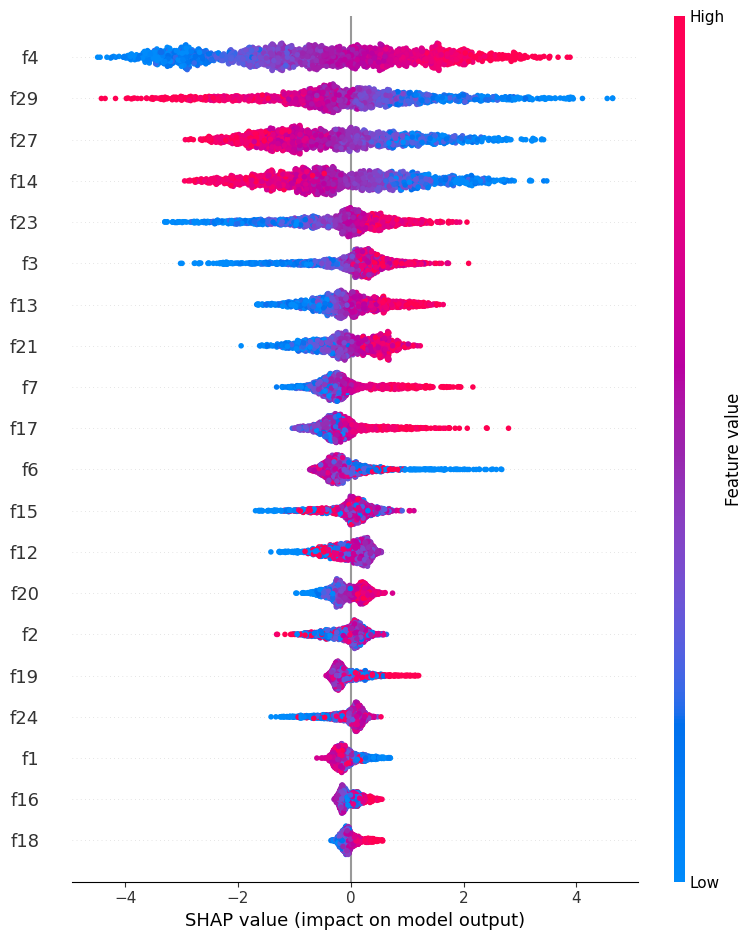

In [4]:
import shap

explainer = shap.TreeExplainer(best)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feat_names, show=True)

## 小結：表格資料的致勝流程

1. **切 train/val/test** —— 測試集鎖到最後
2. **隨機搜尋（或 Optuna）** 找好參數
3. **最佳參數 + early stopping** 重訓，`best_iteration` 拿最佳樹數
4. **測試集驗收** —— classification report + AUC
5. **SHAP** 交出可解釋的洞察

梯度提升是表格資料競賽的王者——你現在有完整的骨架了。

## 練習（綜合）

1. 把模型換成 `LGBMClassifier`，整條流程能否照跑？AUC 差多少？
2. 用 SHAP 找出最沒用的幾個特徵，移除它們重訓，AUC 會掉嗎？
3. 挑戰：把這套流程套到一個真實的 Kaggle 表格資料集。

下一個模組，我們離開樹模型，跳進**深度學習**。